# EDA — Personal Finance Dataset (Opsi 2)

**Perubahan utama dari versi sebelumnya:**
- Label persona bukan dari `avg_ratio` (circular) melainkan dari **distribusi kategori belanja**
- `saver` = user yang proporsi kebutuhan pokoknya relatif tinggi dibanding user lain
- `spender` = user yang proporsi gaya hidupnya relatif tinggi
- `balanced` = di antaranya
- `overspending` tetap rule deterministik: `avg_ratio >= 1.0`
- `avg_ratio` **tidak masuk fitur model** — hanya untuk validasi dan rule overspending

---

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import gaussian_kde
import warnings, json
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor':'white','axes.grid':True,'grid.alpha':0.3,'font.size':11})

PALETTE = {'saver':'#2ecc71','balanced':'#3498db','spender':'#f39c12','overspending':'#e74c3c'}
ORDER   = ['saver','balanced','spender','overspending']

DATA_PATH = 'raw_dataset_personal_finance.csv'
print('Setup selesai.')

Setup selesai.


## 2. Load & Drop `status_user`

In [ ]:
df_raw = pd.read_csv(DATA_PATH)
df_raw['tanggal'] = pd.to_datetime(df_raw['tanggal'])

print('Shape raw:', df_raw.shape)
print('Distribusi status_user (lama):')
print(df_raw['status_user'].value_counts())

df = df_raw.drop(columns=['status_user']).copy()
print('\nKolom setelah drop:', df.columns.tolist())
df.head()

Shape raw: (269743, 9)
Distribusi status_user (lama):
status_user
Normal          229328
Overspending     40415
Name: count, dtype: int64

Kolom setelah drop: ['id_pengguna', 'tanggal', 'bulan', 'tahun', 'Kota', 'Kategori', 'pendapatan_bulanan', 'jumlah_pengeluaran']


,id_pengguna,tanggal,bulan,tahun,Kota,Kategori,pendapatan_bulanan,jumlah_pengeluaran
0,USR000001,2025-06-01,6,2025,Makassar,Perumahan,13788000.0,628000.0
1,USR000001,2025-06-03,6,2025,Makassar,Makanan,13788000.0,563000.0
2,USR000001,2025-06-06,6,2025,Makassar,Hiburan,13788000.0,380000.0
3,USR000001,2025-06-06,6,2025,Makassar,Sosial,13788000.0,238000.0
4,USR000001,2025-06-07,6,2025,Makassar,Hewan Peliharaan,13788000.0,254000.0


## 3. EDA Distribusi Dasar

In [ ]:
print(f'User unik    : {df["id_pengguna"].nunique()}')
print(f'Kota unik    : {df["Kota"].nunique()}')
print(f'Kategori unik: {df["Kategori"].nunique()}  → {sorted(df["Kategori"].unique())}')
txn = df.groupby('id_pengguna').size()
print(f'Transaksi/user: min={txn.min()}, max={txn.max()}, rata={txn.mean():.0f}')

User unik    : 1000
Kota unik    : 55
Kategori unik: 15  → ['Anak-Anak', 'Belanja', 'Elektronik', 'Hewan Peliharaan', 'Hiburan', 'Kesehatan', 'Makanan', 'Olahraga', 'Pakaian', 'Pendidikan', 'Perumahan', 'Sosial', 'Tagihan', 'Transportasi', 'Traveling']
Transaksi/user: min=248, max=291, rata=270


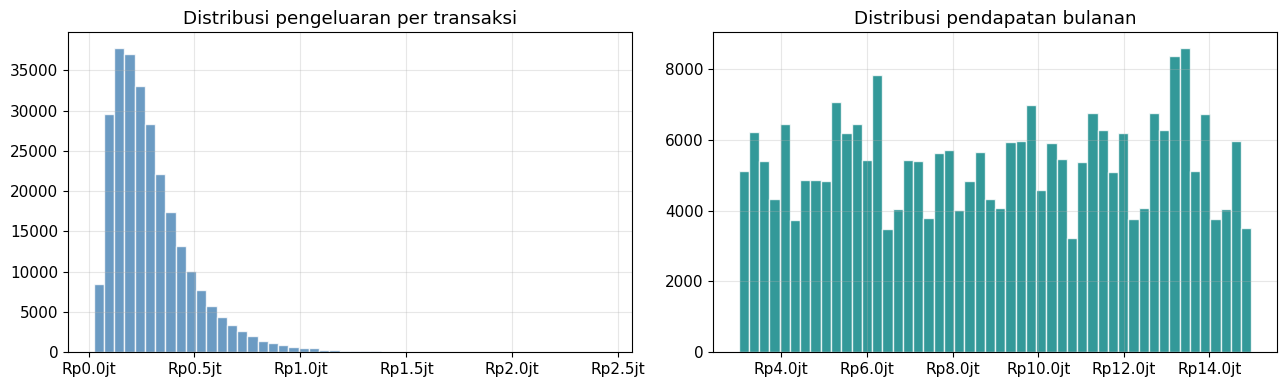

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
axes[0].hist(df['jumlah_pengeluaran'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi pengeluaran per transaksi')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'Rp{x/1e6:.1f}jt'))
axes[1].hist(df['pendapatan_bulanan'], bins=50, color='teal', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribusi pendapatan bulanan')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'Rp{x/1e6:.1f}jt'))
plt.tight_layout()
plt.savefig('eda_01_pengeluaran.png', dpi=120, bbox_inches='tight')
plt.show()

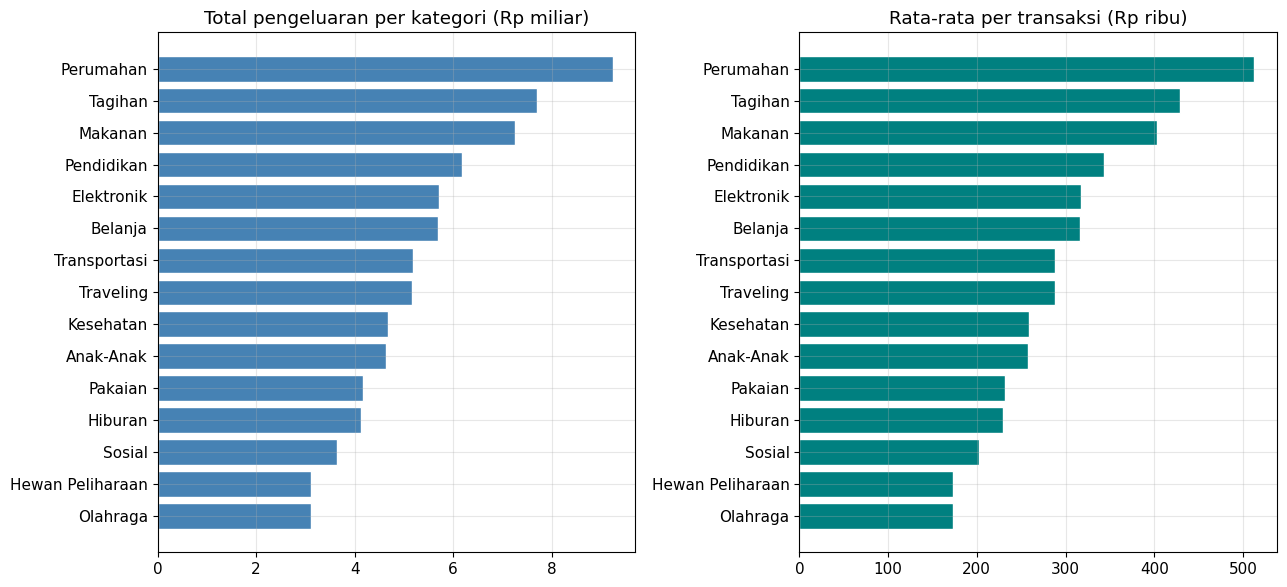

In [ ]:
cat_agg = df.groupby('Kategori')['jumlah_pengeluaran'].agg(['sum','mean']).sort_values('sum',ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(13,6))
axes[0].barh(cat_agg.index, cat_agg['sum']/1e9, color='steelblue', edgecolor='white')
axes[0].set_title('Total pengeluaran per kategori (Rp miliar)')
axes[1].barh(cat_agg.index, cat_agg['mean']/1e3, color='teal', edgecolor='white')
axes[1].set_title('Rata-rata per transaksi (Rp ribu)')
plt.tight_layout()
plt.savefig('eda_02_kategori.png', dpi=120, bbox_inches='tight')
plt.show()

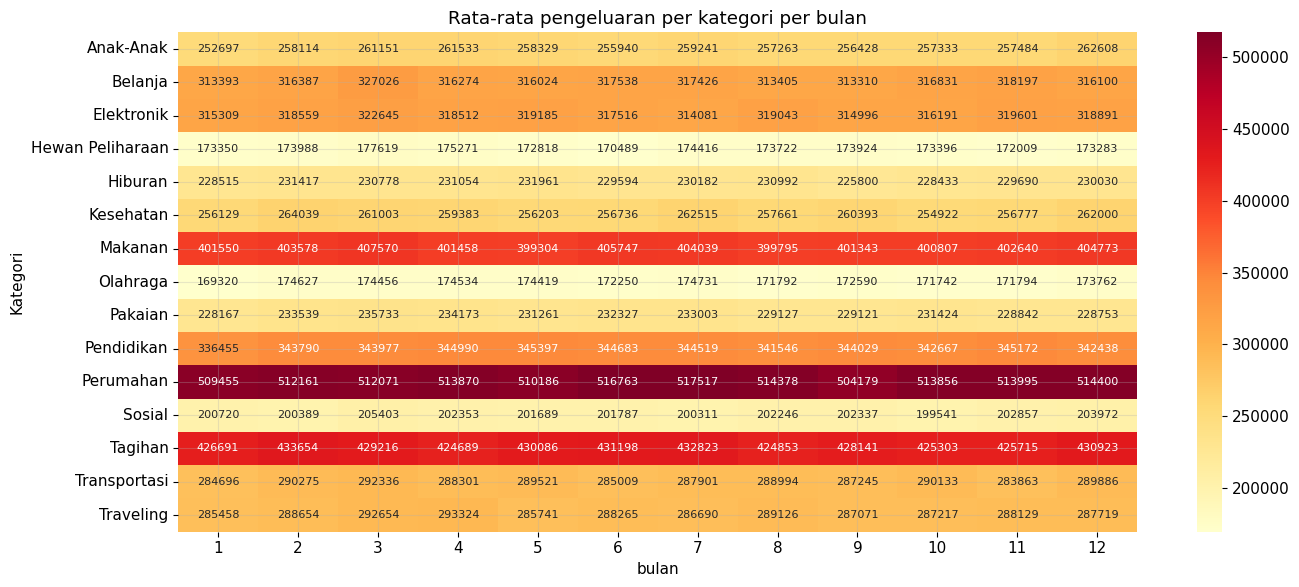

In [ ]:
hm = df.groupby(['bulan','Kategori'])['jumlah_pengeluaran'].mean().unstack()
fig, ax = plt.subplots(figsize=(14,6))
sns.heatmap(hm.T, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f', annot_kws={'size':8})
ax.set_title('Rata-rata pengeluaran per kategori per bulan')
plt.tight_layout()
plt.savefig('eda_03_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Feature Engineering

Fitur yang dibangun:
- Statistik volatilitas bulanan: `std_ratio`, `ratio_range`, `trend`
- Statistik pengeluaran absolut: `avg_keluar`, `std_keluar`, `avg_transaksi`
- Konteks: `pendapatan_bulanan`
- **Distribusi kategori**: `pct_kebutuhan`, `pct_gaya_hidup`, 15 category ratios

`avg_ratio` tetap dihitung tapi **hanya untuk rule overspending dan validasi**.

In [ ]:
# Monthly aggregate
user_monthly = df.groupby(['id_pengguna','bulan','tahun']).agg(
    total_keluar=('jumlah_pengeluaran','sum'),
    pendapatan=('pendapatan_bulanan','first'),
    n_transaksi=('jumlah_pengeluaran','count')
).reset_index()
user_monthly['monthly_ratio'] = user_monthly['total_keluar'] / user_monthly['pendapatan']
user_monthly_s = user_monthly.sort_values(['id_pengguna','tahun','bulan'])

# Stats per user
user_stats = user_monthly.groupby('id_pengguna').agg(
    avg_ratio    =('monthly_ratio','mean'),   # hanya untuk validasi & rule
    std_ratio    =('monthly_ratio','std'),
    min_ratio    =('monthly_ratio','min'),
    max_ratio    =('monthly_ratio','max'),
    avg_keluar   =('total_keluar','mean'),
    std_keluar   =('total_keluar','std'),
    avg_transaksi=('n_transaksi','mean'),
).reset_index().fillna(0)
user_stats['ratio_range'] = user_stats['max_ratio'] - user_stats['min_ratio']

# Trend 3 bulan
last3  = user_monthly_s.groupby('id_pengguna').tail(3).groupby('id_pengguna')['monthly_ratio'].mean()
first3 = user_monthly_s.groupby('id_pengguna').head(3).groupby('id_pengguna')['monthly_ratio'].mean()
user_stats['trend'] = (last3 - first3).values

print('user_stats shape:', user_stats.shape)

user_stats shape: (1000, 10)


In [ ]:
# Category ratios per user
grand = df.groupby('id_pengguna')['jumlah_pengeluaran'].sum().reset_index()
grand.columns = ['id_pengguna','grand_total']
cat = df.groupby(['id_pengguna','Kategori'])['jumlah_pengeluaran'].sum().reset_index()
cat = cat.merge(grand, on='id_pengguna')
cat['cat_ratio'] = cat['jumlah_pengeluaran'] / cat['grand_total']
cat_pivot = cat.pivot_table(index='id_pengguna',columns='Kategori',
                             values='cat_ratio',fill_value=0).reset_index()
cat_pivot.columns = ['id_pengguna' if c=='id_pengguna' else f'cat_{c}'
                     for c in cat_pivot.columns]
CAT_COLS = [c for c in cat_pivot.columns if c!='id_pengguna']
print('Category cols:', CAT_COLS)

Category cols: ['cat_Anak-Anak', 'cat_Belanja', 'cat_Elektronik', 'cat_Hewan Peliharaan', 'cat_Hiburan', 'cat_Kesehatan', 'cat_Makanan', 'cat_Olahraga', 'cat_Pakaian', 'cat_Pendidikan', 'cat_Perumahan', 'cat_Sosial', 'cat_Tagihan', 'cat_Transportasi', 'cat_Traveling']


In [ ]:
# Kelompok kategori finansial
KEBUTUHAN_CATS  = [c for c in ['cat_Perumahan','cat_Makanan','cat_Kesehatan',
                                'cat_Tagihan','cat_Transportasi'] if c in cat_pivot.columns]
GAYAHIDUP_CATS  = [c for c in ['cat_Hiburan','cat_Belanja','cat_Traveling','cat_Pakaian',
                                'cat_Elektronik','cat_Olahraga','cat_Sosial',
                                'cat_Hewan Peliharaan','cat_Anak-Anak','cat_Pendidikan']
                   if c in cat_pivot.columns]

# Identitas
identity = df.groupby('id_pengguna')[['pendapatan_bulanan','Kota']].first().reset_index()
diversity = (df.groupby('id_pengguna')['Kategori'].nunique()
             .reset_index().rename(columns={'Kategori':'diversity'}))

# Gabung semua
user_full = (user_stats
    .merge(cat_pivot, on='id_pengguna')
    .merge(identity, on='id_pengguna')
    .merge(diversity, on='id_pengguna'))

user_full['pct_kebutuhan']  = user_full[KEBUTUHAN_CATS].sum(axis=1)
user_full['pct_gaya_hidup'] = user_full[GAYAHIDUP_CATS].sum(axis=1)

print('user_full shape:', user_full.shape)
user_full.head()

user_full shape: (1000, 30)


,id_pengguna,avg_ratio,std_ratio,min_ratio,max_ratio,avg_keluar,std_keluar,avg_transaksi,ratio_range,trend,...,cat_Perumahan,cat_Sosial,cat_Tagihan,cat_Transportasi,cat_Traveling,pendapatan_bulanan,Kota,diversity,pct_kebutuhan,pct_gaya_hidup
0,USR000001,0.614206,0.102525,0.475704,0.807514,8.468667e+06,1.413621e+06,21.333333,0.331810,-0.102432,...,0.106422,0.054318,0.077570,0.067720,0.065004,13788000.0,Makassar,15,0.410454,0.589546
1,USR000002,0.626547,0.085286,0.511489,0.766689,9.216500e+06,1.254562e+06,23.833333,0.255201,0.032246,...,0.112054,0.045507,0.111539,0.061330,0.063726,14710000.0,Palangka Raya,15,0.435026,0.564974
2,USR000003,0.658174,0.118680,0.479728,0.840322,9.480333e+06,1.709469e+06,23.500000,0.360594,0.288716,...,0.115028,0.051431,0.103495,0.058024,0.062814,14404000.0,Langsa,15,0.428782,0.571218
3,USR000004,0.680312,0.097507,0.524468,0.834628,8.758333e+06,1.255304e+06,22.583333,0.310160,0.106571,...,0.139201,0.045880,0.096927,0.066698,0.073777,12874000.0,Lhokseumawe,15,0.441056,0.558944
4,USR000005,0.649489,0.128925,0.455350,0.840570,3.963833e+06,7.868307e+05,22.083333,0.385220,0.052652,...,0.123302,0.048459,0.081613,0.062650,0.076021,6103000.0,Mataram,15,0.425009,0.574991


## 5. Labeling Opsi 2 — Dari Distribusi Kategori

**Filosofi:**
- `saver` bukan yang paling sedikit belanja, tapi yang **proporsi belanjanya paling banyak ke kebutuhan pokok** relatif terhadap user lain
- `spender` adalah yang **proporsi gaya hidupnya paling dominan**
- Threshold dari **percentile data** — bukan angka absolut — karena dataset sintetis membuat distribusi sangat sempit

**Tidak menggunakan `avg_ratio` sama sekali dalam labeling**.

In [ ]:
# Threshold percentile dari pct_kebutuhan
p33 = user_full['pct_kebutuhan'].quantile(0.33)
p67 = user_full['pct_kebutuhan'].quantile(0.67)

print(f'Statistik pct_kebutuhan:')
print(user_full['pct_kebutuhan'].describe(percentiles=[.25,.33,.5,.67,.75]).round(6))
print(f'\np33 = {p33:.6f}')
print(f'p67 = {p67:.6f}')

def assign_persona(row):
    if row['avg_ratio'] >= 1.0:         return 'overspending'  # rule deterministik
    elif row['pct_kebutuhan'] >= p67:   return 'saver'
    elif row['pct_kebutuhan'] <= p33:   return 'spender'
    else:                               return 'balanced'

user_full['persona'] = user_full.apply(assign_persona, axis=1)

print('\n=== DISTRIBUSI PERSONA (Opsi 2) ===')
print(user_full['persona'].value_counts())
print()
print('Rata-rata fitur per persona:')
print(user_full.groupby('persona')[
    ['avg_ratio','std_ratio','pct_kebutuhan','pct_gaya_hidup','trend']
].mean().round(4))

Statistik pct_kebutuhan:
count    1000.000000
mean        0.427500
std         0.015227
min         0.379985
25%         0.416840
33%         0.420485
50%         0.427885
67%         0.434930
75%         0.438400
max         0.471760
Name: pct_kebutuhan, dtype: float64

p33 = 0.420485
p67 = 0.434930

=== DISTRIBUSI PERSONA (Opsi 2) ===
persona
balanced        289
spender         284
saver           277
overspending    150
Name: count, dtype: int64

Rata-rata fitur per persona:
              avg_ratio  std_ratio  pct_kebutuhan  pct_gaya_hidup   trend
persona                                                                  
balanced         0.6502     0.1143         0.4279          0.5721  0.0058
overspending     1.1960     0.0875         0.4284          0.5716  0.0024
saver            0.6516     0.1136         0.4442          0.5558  0.0044
spender          0.6525     0.1119         0.4104          0.5896  0.0031


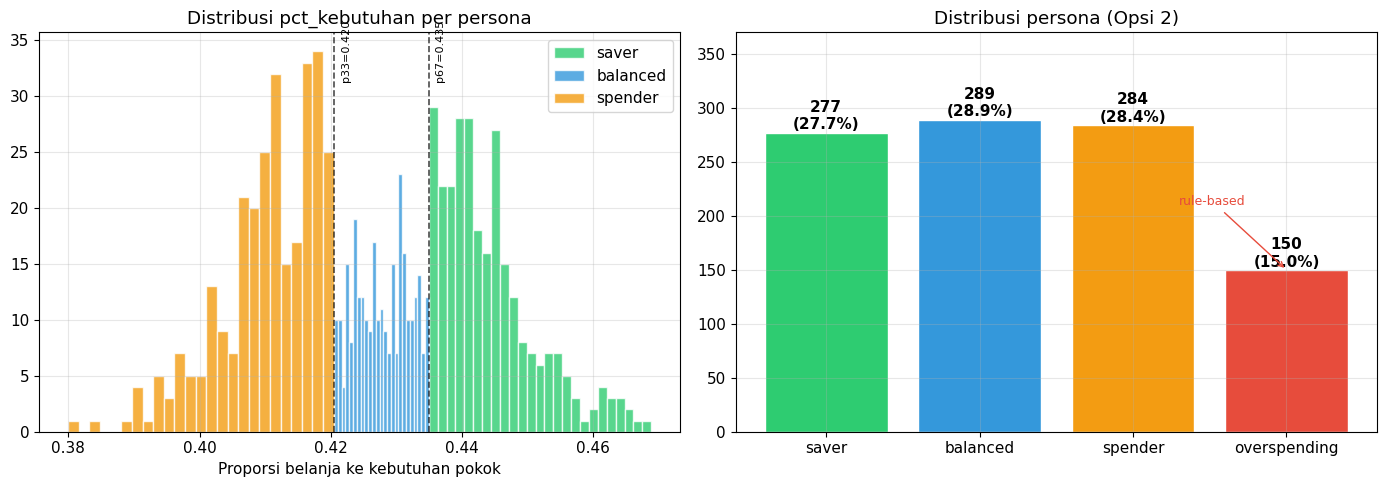

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
r = user_full['pct_kebutuhan']

for p, color in PALETTE.items():
    if p == 'overspending': continue
    mask = user_full['persona'] == p
    axes[0].hist(r[mask], bins=25, color=color, edgecolor='white', alpha=0.8, label=p)

axes[0].axvline(p33, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].axvline(p67, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
axes[0].text(p33+0.001, axes[0].get_ylim()[1]*0.88, f'p33={p33:.3f}', fontsize=8, rotation=90)
axes[0].text(p67+0.001, axes[0].get_ylim()[1]*0.88, f'p67={p67:.3f}', fontsize=8, rotation=90)
axes[0].set_title('Distribusi pct_kebutuhan per persona')
axes[0].set_xlabel('Proporsi belanja ke kebutuhan pokok')
axes[0].legend()

dist = user_full['persona'].value_counts()
counts = [dist.get(p,0) for p in ORDER]
bars = axes[1].bar(ORDER, counts, color=[PALETTE[p] for p in ORDER], edgecolor='white')
for bar, cnt in zip(bars, counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 f'{cnt}\n({cnt/10:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Distribusi persona (Opsi 2)')
axes[1].set_ylim(0, max(counts)*1.28)

# Anotasi overspending sebagai rule
axes[1].annotate('rule-based', xy=(3, dist.get('overspending',0)),
                 xytext=(2.3, dist.get('overspending',0)+60),
                 arrowprops=dict(arrowstyle='->', color='#e74c3c'),
                 color='#e74c3c', fontsize=9)
plt.tight_layout()
plt.savefig('eda_04_persona_opsi2.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Validasi: apakah persona berbeda secara statistik?
from scipy.stats import f_oneway
print('ANOVA test — pemisahan antar persona:')
for feat in ['pct_kebutuhan','pct_gaya_hidup','std_ratio','avg_ratio']:
    groups = [user_full[user_full['persona']==p][feat]
              for p in ['saver','balanced','spender']]
    f, pval = f_oneway(*groups)
    sig = '✓ signifikan' if pval < 0.05 else '✗ tidak signifikan'
    print(f'  {feat:<20}: F={f:8.2f}, p={pval:.4f}  {sig}')

print()
print('Catatan: pct_kebutuhan signifikan karena label dibuat dari sana.')
print('Perhatikan std_ratio dan avg_ratio — jika signifikan, berarti')
print('persona kategori juga berkorelasi dengan perilaku belanja lainnya.')

ANOVA test — pemisahan antar persona:
  pct_kebutuhan       : F= 1883.67, p=0.0000  ✓ signifikan
  pct_gaya_hidup      : F= 1883.67, p=0.0000  ✓ signifikan
  std_ratio           : F=    1.57, p=0.2095  ✗ tidak signifikan
  avg_ratio           : F=    0.31, p=0.7318  ✗ tidak signifikan

Catatan: pct_kebutuhan signifikan karena label dibuat dari sana.
Perhatikan std_ratio dan avg_ratio — jika signifikan, berarti
persona kategori juga berkorelasi dengan perilaku belanja lainnya.


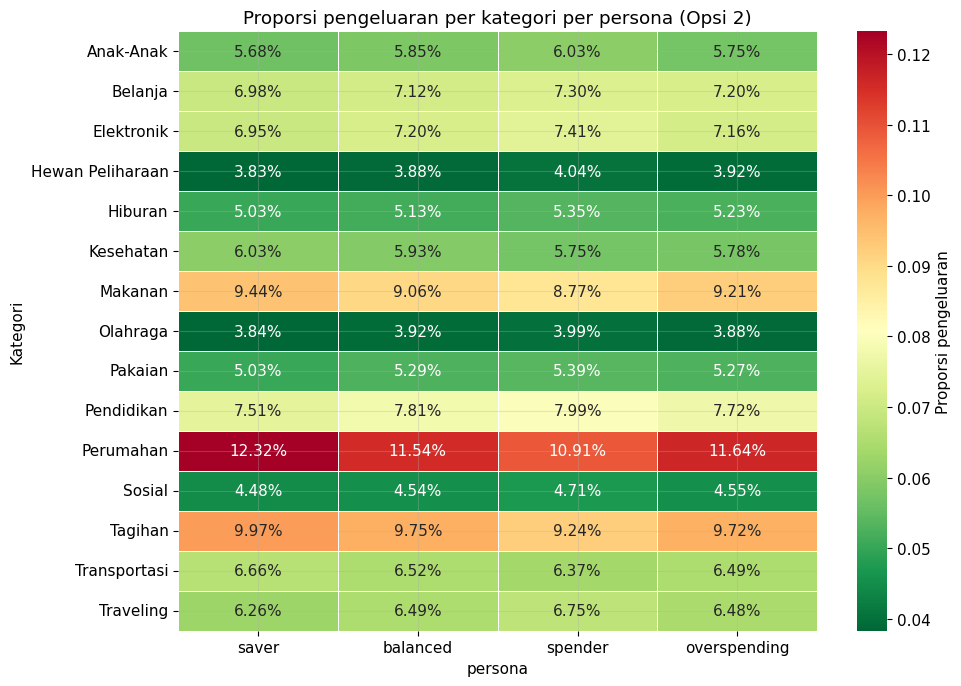

In [ ]:
# Heatmap pola kategori per persona
cat_persona = df.merge(user_full[['id_pengguna','persona']], on='id_pengguna')
cp = cat_persona.groupby(['persona','Kategori'])['jumlah_pengeluaran'].sum().reset_index()
tot = cat_persona.groupby('persona')['jumlah_pengeluaran'].sum().reset_index()
tot.columns = ['persona','total']
cp = cp.merge(tot, on='persona')
cp['ratio_cat'] = cp['jumlah_pengeluaran'] / cp['total']
pivot = cp.pivot(index='Kategori', columns='persona', values='ratio_cat')
pivot = pivot[['saver','balanced','spender','overspending']]

fig, ax = plt.subplots(figsize=(10,7))
sns.heatmap(pivot, annot=True, fmt='.2%', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, cbar_kws={'label':'Proporsi pengeluaran'})
ax.set_title('Proporsi pengeluaran per kategori per persona (Opsi 2)')
plt.tight_layout()
plt.savefig('eda_05_heatmap_persona.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Simpan Output EDA

In [ ]:
# Simpan label dan threshold
user_full[['id_pengguna','avg_ratio','pct_kebutuhan','pct_gaya_hidup','persona']]    .to_csv('user_persona_labels_opsi2.csv', index=False)

thresholds = {
    'method'              : 'opsi2_category_based',
    'p33_pct_kebutuhan'   : float(p33),
    'p67_pct_kebutuhan'   : float(p67),
    'overspending_threshold': 1.0,
    'kebutuhan_categories': ['Perumahan','Makanan','Kesehatan','Tagihan','Transportasi'],
    'gayahidup_categories': ['Hiburan','Belanja','Traveling','Pakaian','Elektronik',
                             'Olahraga','Sosial','Hewan Peliharaan','Anak-Anak','Pendidikan'],
    'label_logic': {
        'overspending': 'avg_ratio >= 1.0 (rule)',
        'saver'       : 'pct_kebutuhan >= p67',
        'balanced'    : 'p33 < pct_kebutuhan < p67',
        'spender'     : 'pct_kebutuhan <= p33',
    }
}
with open('persona_thresholds.json','w') as f:
    json.dump(thresholds, f, indent=2, ensure_ascii=False)

print('Tersimpan: user_persona_labels_opsi2.csv')
print('Tersimpan: persona_thresholds.json')
print()
dist = user_full['persona'].value_counts()
for p in ORDER:
    tag = ' [rule]' if p=='overspending' else ' [model - dari kategori]'
    print(f'  {p:<14}: {dist.get(p,0):4d} user{tag}')

Tersimpan: user_persona_labels_opsi2.csv
Tersimpan: persona_thresholds.json

  saver         :  277 user [model - dari kategori]
  balanced      :  289 user [model - dari kategori]
  spender       :  284 user [model - dari kategori]
  overspending  :  150 user [rule]
